In [117]:
!pip install numpy
!pip install matplotlib
!pip install scipy

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [118]:
import json
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde


In [119]:
scene = "scene053"
data_path = f"generated_scenes/{scene}/results/square_wood_block_positions.npy"
truth_path = f"generated_scenes/{scene}/data/{scene}_truth.json"

positions = np.load(data_path)
positions = positions.reshape(-1, 7)

x = positions[:, 0]
y = positions[:, 1]

In [120]:
with open(truth_path, 'r') as f:
    truth_data = json.load(f)

x_min = min(x.min(), np.min([row[0] for row in truth_data.values()])) - .1
y_min = min(y.min(), np.min([row[1] for row in truth_data.values()])) - .1

x_max = max(x.max(), np.max([row[0] for row in truth_data.values()])) + .1
y_max = max(y.max(), np.max([row[1] for row in truth_data.values()])) + .1

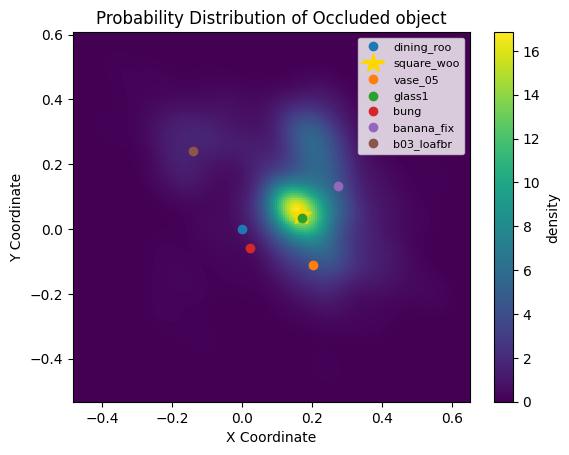

In [121]:
xy = np.vstack([x, y])
kde = gaussian_kde(xy)

# evaluate on a grid
xi, yi = np.mgrid[x_min:x_max:200j, y_min:y_max:200j]
zi = kde(np.vstack([xi.ravel(), yi.ravel()])).reshape(xi.shape)

plt.pcolormesh(xi, yi, zi, cmap='viridis', shading='auto')
plt.colorbar(label='density')

for obj, loc in truth_data.items():
    name = obj[:min(10, len(obj))]

    if obj == "square_wood_block":
        plt.plot(
            truth_data["square_wood_block"][0],
            truth_data["square_wood_block"][1],
            marker="*",
            markersize=15,
            label="square_wood_block"[0:10],
            c="gold",
         )

        continue
    plt.plot(loc[0], loc[1], 'o', markersize=5, markeredgewidth=2, label=name)


plt.title("Probability Distribution of Occluded object")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.legend(fontsize=8)
plt.show()